# Week 2 - Tesla Deliveries: EDA, Feature Engineering and Forecasting

**Author:** Yuvraj

**Dataset:** `tesla_deliveries_dataset_2015_2025.csv` (monthly Tesla delivery records from 2015 to 2025, broken down by Region and Model)

The goal of this notebook is to take the raw delivery data and walk it all the way through to a working forecast.
I start by loading and profiling the data so I know what I am dealing with, then explore it visually, engineer a
couple of time-aware features, and finally train and compare two regression models. Because this is delivery data
that moves through time, I am careful to split the data chronologically rather than randomly, so the model is always
predicting the future from the past and never the other way around.

A few additions go beyond the core checklist: a per-model trend breakdown, permutation importance to double-check
the feature rankings, and a residual diagnostic at the end. I have called these out where they appear so it is clear
what is required versus what I added on top.

## 0. Setup and Imports



In [1]:
# Core data-handling and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and the two regression models I compare
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model selection and validation utilities
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Statistical test for stationarity (used in the time-series section)
from statsmodels.tsa.stattools import adfuller

# One visual style applied across the whole notebook so the charts look consistent
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
PALETTE = "viridis"          # reused everywhere so the colours stay coherent
np.random.seed(42)           # fixed seed keeps results reproducible across runs

## 1. Loading the Dataset and Getting a First Look

Before doing anything clever, I want to understand the shape of the data: how many rows and columns there are, what
the columns are called, what types they hold, and roughly what range the numbers fall into. The four calls below
(`shape`, `columns`, `.info()`, `.describe()`) answer all of that and are the first thing I reach for on any new
dataset.

In [2]:
# Load the CSV into a DataFrame.
# If running on Colab, upload the file first (files.upload()) and the path below will still work.
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)                 # number of (rows, columns)
print("\nColumns:", list(df.columns))

Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [3]:
# .info() shows the dtype of each column and confirms whether any values are missing
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [4]:
# .describe() summarises the spread of every numeric column (mean, std, min, quartiles, max)
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [5]:
# A quick peek at the first few rows to see actual values rather than just summaries
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 2. Checking Data Quality

A model is only as trustworthy as the data underneath it, so before modelling I check the two things that most
commonly cause trouble: missing values and duplicate rows. Missing values can quietly break calculations or bias a
model, and duplicate rows inflate certain patterns and make the data look more confident than it really is.

In [6]:
# Count missing values in every column and only print the ones that actually have gaps
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() else "None - the dataset is fully populated.")

# Count exact duplicate rows; drop them if any exist so they do not skew the analysis
dups = df.duplicated().sum()
print(f"\nDuplicate rows: {dups}")
if dups:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Dropped duplicates ->", df.shape)

Missing values per column:
None - the dataset is fully populated.

Duplicate rows: 0


### Building a proper time axis (added step)

This dataset arrives shuffled: the rows are not in date order, they jump around between years and months. That is a
problem because Step 5 asks for a chronological train/test split, and "chronological" is meaningless until the rows
are actually sorted by time. So here I combine the `Year` and `Month` columns into a single `Date` timestamp and
sort the whole frame by it. Every later step that depends on ordering (the lag feature, the rolling mean, the split,
and the stationarity test) relies on this one cell being correct.

In [7]:
# Combine Year and Month into a single date (day fixed to the 1st since the data is monthly)
df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

# Sort chronologically so the rows run from earliest to latest, then reset the index
df = df.sort_values("Date").reset_index(drop=True)

print("Time span:", df["Date"].min().date(), "->", df["Date"].max().date())
df[["Date", "Region", "Model", "Estimated_Deliveries"]].head()

Time span: 2015-01-01 -> 2025-12-01


,Date,Region,Model,Estimated_Deliveries
0,2015-01-01,Asia,Model Y,12446
1,2015-01-01,Middle East,Model 3,11446
2,2015-01-01,Middle East,Cybertruck,8803
3,2015-01-01,North America,Cybertruck,6367
4,2015-01-01,Asia,Model 3,8795


## 3. Exploratory Data Analysis

This section builds the five charts the brief asks for: deliveries by Model, deliveries by Region, a correlation
heatmap, a Production-versus-Deliveries scatter, and an overall time trend. Each chart has a title and labelled axes
so it can stand on its own. The aim here is not just to tick boxes but to actually understand which variables matter,
which is exactly the intuition I will lean on when choosing features later.

### 3.1 Total Deliveries by Model

Summing deliveries across the whole period for each model shows which cars carry the volume. I expect the
mass-market models to dominate the premium ones.

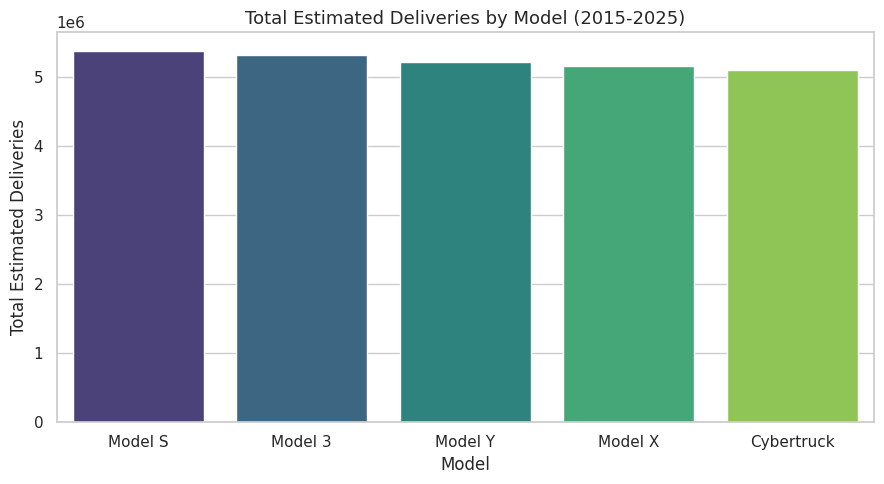

In [8]:
# Aggregate total deliveries per model and sort so the biggest sellers appear first
by_model = df.groupby("Model")["Estimated_Deliveries"].sum().sort_values(ascending=False)

ax = sns.barplot(x=by_model.index, y=by_model.values, palette=PALETTE, hue=by_model.index, legend=False)
ax.set_title("Total Estimated Deliveries by Model (2015-2025)")
ax.set_xlabel("Model")
ax.set_ylabel("Total Estimated Deliveries")
plt.tight_layout()
plt.show()

### 3.2 Total Deliveries by Region

The same aggregation, this time grouped by region, tells me whether sales are concentrated in one part of the world
or spread fairly evenly.

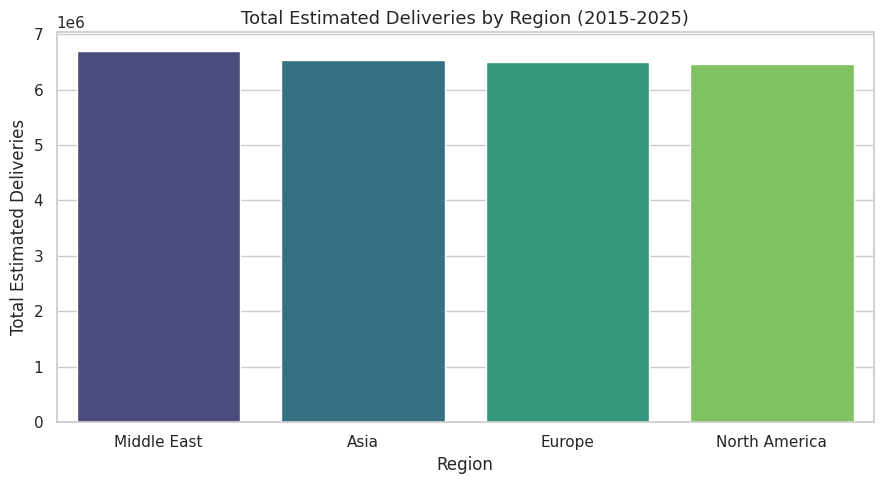

In [9]:
# Aggregate total deliveries per region, largest first
by_region = df.groupby("Region")["Estimated_Deliveries"].sum().sort_values(ascending=False)

ax = sns.barplot(x=by_region.index, y=by_region.values, palette=PALETTE, hue=by_region.index, legend=False)
ax.set_title("Total Estimated Deliveries by Region (2015-2025)")
ax.set_xlabel("Region")
ax.set_ylabel("Total Estimated Deliveries")
plt.tight_layout()
plt.show()

### 3.3 Correlation Heatmap

The heatmap is the single most useful EDA chart for a regression task because it shows, at a glance, which numeric
features move together. The one relationship I am specifically watching for is Production_Units against
Estimated_Deliveries: deliveries cannot exceed what is produced, so I expect these two to be very strongly
correlated (somewhere above 0.9).

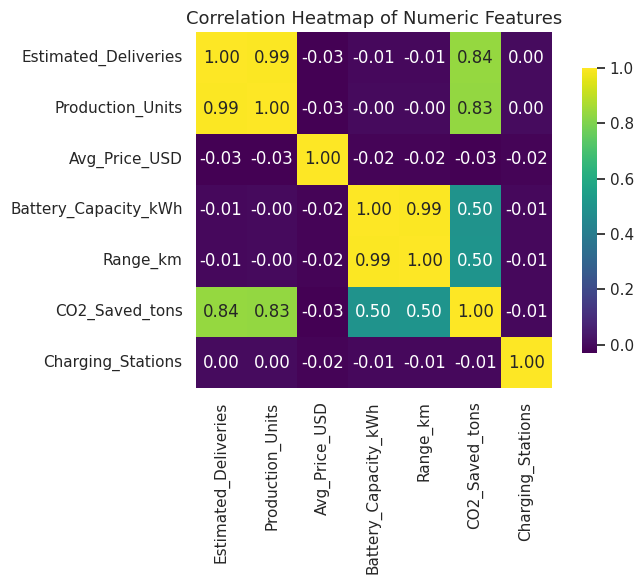

Production_Units vs Estimated_Deliveries correlation: 0.994


In [10]:
# Correlation only makes sense on numeric columns; Year and Month are dropped because
# they are calendar labels rather than measured quantities
num_cols = df.select_dtypes(include=np.number).drop(columns=["Year", "Month"])
corr = num_cols.corr()

plt.figure(figsize=(8, 6))
ax = sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", square=True, cbar_kws={"shrink": .8})
ax.set_title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

# Print the specific correlation the brief asks me to confirm
print("Production_Units vs Estimated_Deliveries correlation:",
      round(corr.loc["Production_Units", "Estimated_Deliveries"], 3))

### 3.4 Production Units vs Estimated Deliveries

The heatmap gives a single number for the production-deliveries link; this scatter shows the actual shape of that
relationship. Colouring by model also reveals whether different cars sit on different parts of the line.

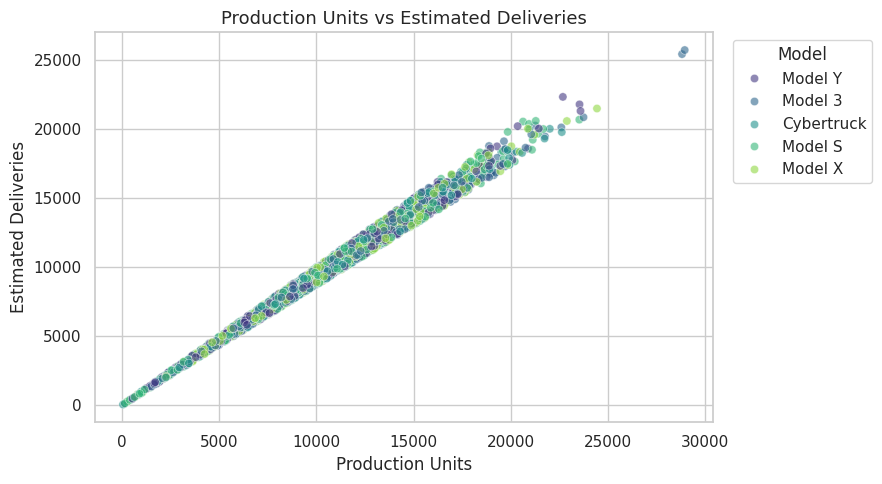

In [11]:
# Scatter of the two most related variables, coloured by model to see per-model structure
ax = sns.scatterplot(data=df, x="Production_Units", y="Estimated_Deliveries",
                     hue="Model", alpha=0.6, palette=PALETTE)
ax.set_title("Production Units vs Estimated Deliveries")
ax.set_xlabel("Production Units")
ax.set_ylabel("Estimated Deliveries")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 3.5 Time Trend of Monthly Deliveries

Summing deliveries by month and plotting them over time shows the long-run growth story and whether there are any
obvious seasonal swings or jumps.

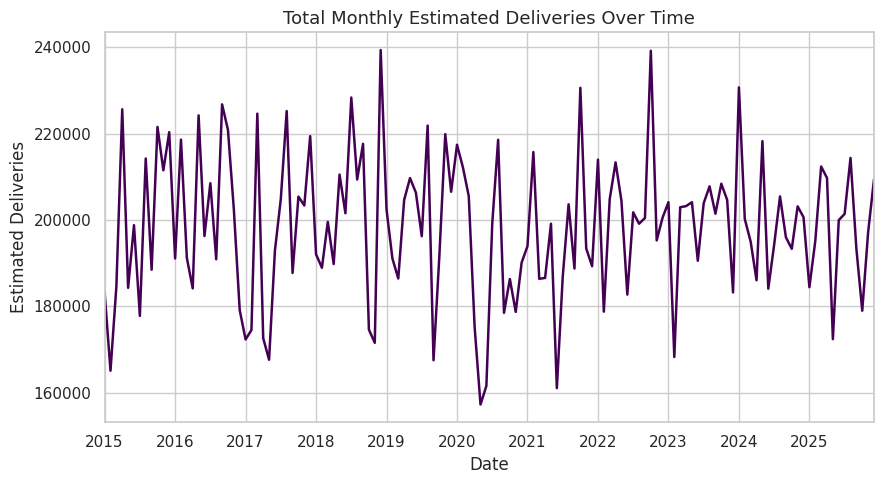

In [12]:
# Total deliveries per month across all regions and models
monthly = df.groupby("Date")["Estimated_Deliveries"].sum()

ax = monthly.plot(color="#440154", lw=1.8)
ax.set_title("Total Monthly Estimated Deliveries Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Estimated Deliveries")
plt.tight_layout()
plt.show()

### 3.6 Per-Model Trend (added chart)

The aggregate trend above is useful but it hides which models are actually driving the growth. Breaking the same
time series out by model is far more informative and is usually the first follow-up question anyone asks after seeing
the total line, so I have added it here.

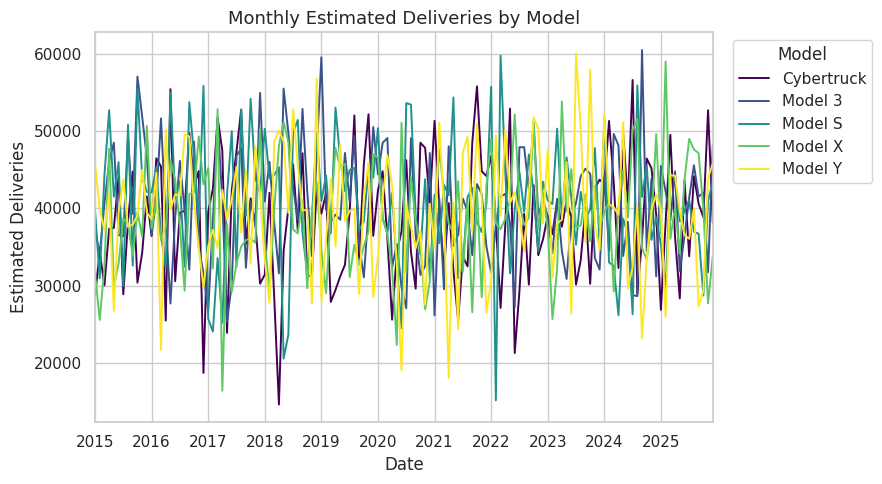

In [13]:
# Pivot so each model becomes its own line over time
model_trend = df.groupby(["Date", "Model"])["Estimated_Deliveries"].sum().unstack()

ax = model_trend.plot(lw=1.4, colormap="viridis")
ax.set_title("Monthly Estimated Deliveries by Model")
ax.set_xlabel("Date")
ax.set_ylabel("Estimated Deliveries")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**What the EDA tells me.** The clearest signal by far is that production and deliveries move almost in lockstep,
which makes `Production_Units` the obvious anchor feature for any model I build. Deliveries trend upward across the
decade, with the higher-volume models contributing most of that growth, while the regional totals are reasonably
balanced rather than dominated by a single market. Practically, this means a plain linear model built mainly on
production should already do very well, and any fancier model has to justify itself against that strong baseline.


## 4. Feature Engineering

Two jobs here. First, the three text columns (Region, Model, Source_Type) need to become numbers before any
scikit-learn model will accept them, so I label-encode each one. Second, because this is time-series data, I add two
features that give the model a sense of recent history: `Deliveries_Lag1`, which is simply last period's deliveries,
and `Rolling_Mean_3`, the average of the last three periods. Both of these create a few empty values at the very
start of the series (there is no "previous" value for the first row), and I fill those gaps with the column mean so
that nothing downstream ever sees a NaN.

In [14]:
# Work on a copy so the original df stays clean and the encoding step is reversible if needed
df_fe = df.copy()

# Label-encode each categorical column and keep the fitted encoder so the mapping stays inspectable
encoders = {}
for col in ["Region", "Model", "Source_Type"]:
    le = LabelEncoder()
    df_fe[col + "_enc"] = le.fit_transform(df_fe[col])
    encoders[col] = le
    # Print the category-to-number mapping so the encoding is transparent
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Region: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model: {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}
Source_Type: {'Estimated (Region)': np.int64(0), 'Interpolated (Month)': np.int64(1), 'Official (Quarter)': np.int64(2)}


In [15]:
# Lag feature: deliveries from the previous time step (shift by one row)
df_fe["Deliveries_Lag1"] = df_fe["Estimated_Deliveries"].shift(1)

# Rolling feature: average deliveries over the last three time steps (smooths short-term noise)
df_fe["Rolling_Mean_3"] = df_fe["Estimated_Deliveries"].rolling(window=3).mean()

# shift() and rolling() leave NaNs at the start of the series; fill them with the column mean
# so no missing values remain in the modelling features
df_fe["Deliveries_Lag1"] = df_fe["Deliveries_Lag1"].fillna(df_fe["Deliveries_Lag1"].mean())
df_fe["Rolling_Mean_3"] = df_fe["Rolling_Mean_3"].fillna(df_fe["Rolling_Mean_3"].mean())

# Confirm the requirement that no NaN is left behind
print("Remaining NaNs in engineered features:",
      int(df_fe[["Deliveries_Lag1", "Rolling_Mean_3"]].isnull().sum().sum()))

Remaining NaNs in engineered features: 0


In [16]:
# Define exactly which columns feed the model and what it is predicting.
# Raw text columns are excluded; their encoded versions are used instead.
feature_cols = [
    "Production_Units", "Avg_Price_USD", "Battery_Capacity_kWh", "Range_km",
    "CO2_Saved_tons", "Charging_Stations",
    "Region_enc", "Model_enc", "Source_Type_enc",
    "Deliveries_Lag1", "Rolling_Mean_3",
]
target_col = "Estimated_Deliveries"

X = df_fe[feature_cols]
y = df_fe[target_col]
print("Feature matrix:", X.shape)

Feature matrix: (2640, 11)


**Why these features.** The lag and rolling-mean features give the model a short memory of recent demand, which
is standard practice in forecasting because the near future usually looks a lot like the recent past. Filling the
handful of starting NaNs with the column mean is a deliberately neutral choice: it avoids inventing a trend and,
importantly, never reaches forward in time to borrow a future value, which would leak information the model should
not have at prediction time.

## 5. Chronological Split and Linear Regression

This is the step where time-series discipline matters most. Instead of `train_test_split`, which shuffles rows
randomly, I slice the already-sorted data by index: the first 80 percent of rows (the earlier dates) become the
training set and the last 20 percent (the most recent dates) become the test set. This mirrors reality, where you
only ever have the past to predict the future, and it gives an honest estimate of how the model would actually
perform going forward.

In [17]:
# 80/20 cut-off point by position, not by random sampling
split_idx = int(len(df_fe) * 0.8)

# Earlier rows train the model; later rows test it
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape[0]} rows ({X_train.shape[0]/len(X):.0%})")
print(f"Test:  {X_test.shape[0]} rows ({X_test.shape[0]/len(X):.0%})")

Train: 2112 rows (80%)
Test:  528 rows (20%)


In [18]:
# Train a plain linear regression as the baseline model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Small helper so every model is reported with the same three metrics
def report(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name:22s} MAE={mae:9.2f}  RMSE={rmse:9.2f}  R2={r2:.4f}")
    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = report("Linear Regression", y_test, y_pred_lr)

Linear Regression      MAE=   322.91  RMSE=   391.80  R2=0.9885


### 5.1 Actual vs Predicted

The scatter below plots predicted deliveries against the true values. The dashed line is where a perfect prediction
would land, so the tighter the points hug that line, the better the model is doing.

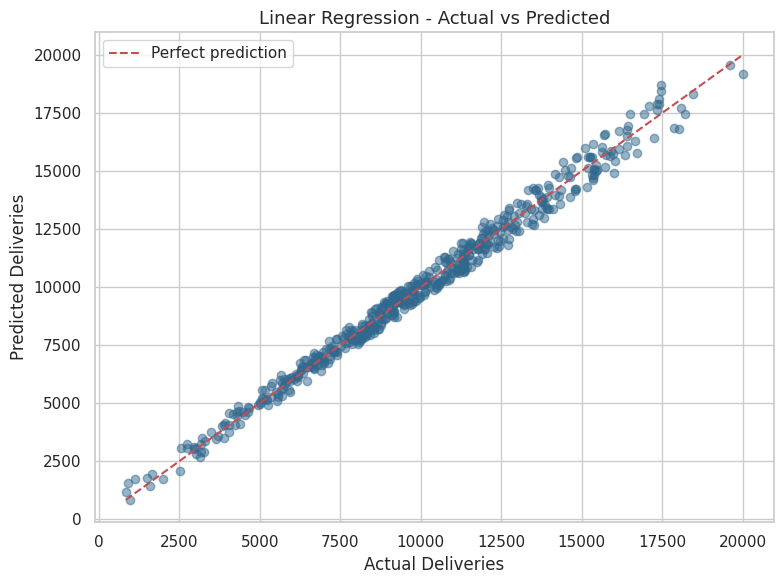

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color="#31688e")

# y = x reference line representing a perfect prediction
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")

plt.title("Linear Regression - Actual vs Predicted")
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Five-Fold Cross-Validation

A single train/test split tells me how the model did on one particular slice of data, but that could be luck. Cross-
validation repeats the evaluation across five different folds and reports the spread, so I can see whether the model
is genuinely stable or just happened to do well once. I look at both the mean R-squared and its standard deviation:
a high mean with a small standard deviation is the reassuring combination.

In [20]:
# Five-fold cross-validation scored on R-squared
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")

for i, s in enumerate(cv_scores, 1):
    print(f"Fold {i}: R2 = {s:.4f}")

print(f"\nMean R2 = {cv_scores.mean():.4f}  (std = {cv_scores.std():.4f})")

Fold 1: R2 = 0.9902
Fold 2: R2 = 0.9911
Fold 3: R2 = 0.9909
Fold 4: R2 = 0.9907
Fold 5: R2 = 0.9885

Mean R2 = 0.9903  (std = 0.0010)


**Reading the cross-validation.** A high average R-squared paired with a small standard deviation means the
model performs consistently no matter which part of the data is held out, which is what I want to see before
trusting it. A large spread between folds would be a warning that the earlier single-split result was not
representative.

## 7. Tuning a Random Forest with GridSearchCV

Now I try a more flexible model. A random forest can capture non-linear patterns that linear regression cannot, but
it has knobs that need setting. GridSearchCV tries every combination of the values I give it, using cross-validation
to judge each one, and hands back the best configuration. I then retrain that best forest on the training set,
evaluate it on the untouched test set, and look at which features it leaned on most.

In [21]:
# Grid of hyperparameters to search over. The first two are required by the brief;
# min_samples_leaf is an extra knob I added to give the search more room.
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 2],
}

# cv=5 means each combination is judged by five-fold cross-validation; n_jobs=-1 uses all cores
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=5, scoring="r2", n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV R2 :", round(grid.best_score_, 4))

# Evaluate the winning model on the held-out test set
best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
rf_mae, rf_rmse, rf_r2 = report("Random Forest (tuned)", y_test, y_pred_rf)

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV R2 : 0.989
Random Forest (tuned)  MAE=   328.98  RMSE=   408.40  R2=0.9875


### 7.1 Feature Importances

A random forest can report how much each feature contributed to its splits. Plotting the top ten makes it obvious
which variables the model actually relies on. Given everything the EDA showed, I expect production and the lag
feature near the top.

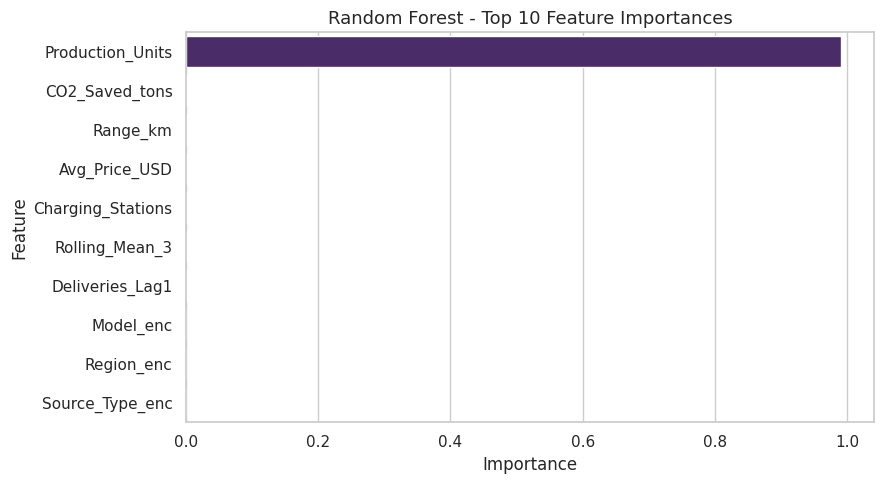

Most important feature: Production_Units


In [22]:
# Pull the forest's built-in importance scores and keep the ten largest
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top10 = importances.head(10)

ax = sns.barplot(x=top10.values, y=top10.index, palette=PALETTE, hue=top10.index, legend=False)
ax.set_title("Random Forest - Top 10 Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

print("Most important feature:", importances.index[0])

### 7.2 Permutation Importance (added check)

The forest's built-in importance can be misleading because it tends to favour features that take many distinct
values. Permutation importance is a more honest, model-agnostic alternative: it shuffles one feature at a time and
measures how much the test score drops as a result. If a feature really matters, scrambling it should hurt
performance noticeably. When both methods agree on the top features, I can trust the ranking a lot more.

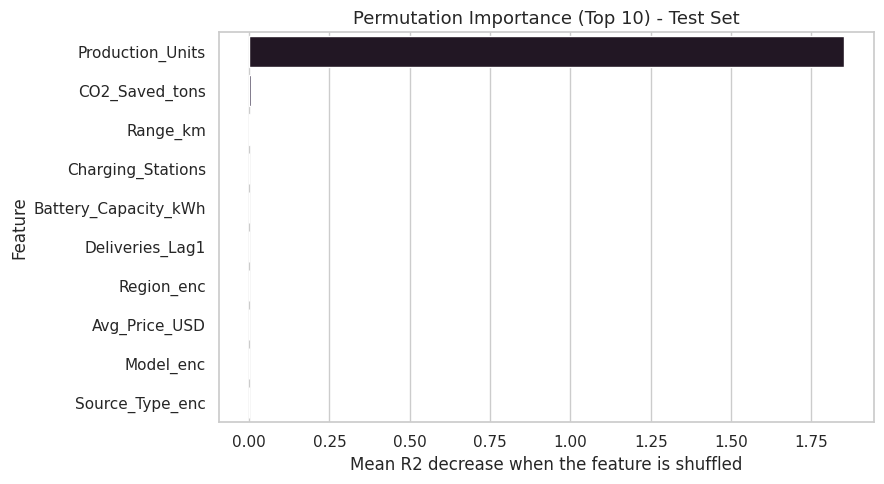

In [23]:
# Shuffle each feature 10 times and measure the average drop in test R-squared
perm = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False).head(10)

ax = sns.barplot(x=perm_imp.values, y=perm_imp.index, palette="mako", hue=perm_imp.index, legend=False)
ax.set_title("Permutation Importance (Top 10) - Test Set")
ax.set_xlabel("Mean R2 decrease when the feature is shuffled")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## 8. Stationarity Check with the Augmented Dickey-Fuller Test

Many time-series methods assume the series is stationary, meaning its statistical behaviour (roughly, its mean and
variance) does not drift over time. The Augmented Dickey-Fuller test checks this formally. The rule I follow is the
standard one: if the p-value is below 0.05, I reject the null hypothesis of a unit root and conclude the series is
stationary; if it is above 0.05, I cannot make that claim and the series is treated as non-stationary.

In [24]:
# Run the ADF test on the time-ordered delivery series
series = df_fe.sort_values("Date")["Estimated_Deliveries"]

adf_stat, p_value, n_lags, n_obs, crit, _ = adfuller(series, autolag="AIC")

print(f"ADF Statistic : {adf_stat:.4f}")
print(f"p-value       : {p_value:.4f}")
print("Critical values:")
for k, v in crit.items():
    print(f"   {k}: {v:.4f}")

# Apply the p < 0.05 decision rule
if p_value < 0.05:
    print("\nConclusion: p < 0.05, so reject H0. The series is STATIONARY.")
else:
    print("\nConclusion: p >= 0.05, so fail to reject H0. The series is NON-STATIONARY.")

ADF Statistic : -51.4057
p-value       : 0.0000
Critical values:
   1%: -3.4328
   5%: -2.8626
   10%: -2.5674

Conclusion: p < 0.05, so reject H0. The series is STATIONARY.


**What the result means.** A stationary series has a stable mean and variance over time, which is convenient
because most forecasting tools assume exactly that and need no further preparation. If the test had instead pointed
to a non-stationary series, the usual next move would be to difference the series before going further. 

## 9. Forecast Table

Metrics summarise performance into a single number, but it is also worth seeing the predictions row by row. The
table below lines up the actual deliveries against the random forest's predictions for the first twenty test
records, and adds an absolute error percentage for each so it is easy to spot where the model is tight and where it
drifts.

In [25]:
# Build a readable comparison table for the first 20 test rows
forecast = pd.DataFrame({
    "Date":      df_fe.iloc[split_idx:]["Date"].values[:20],
    "Model":     df_fe.iloc[split_idx:]["Model"].values[:20],
    "Actual":    y_test.values[:20],
    "Predicted": np.round(y_pred_rf[:20]).astype(int),
})

# Absolute error and error as a percentage of the actual value
forecast["Abs_Error"] = (forecast["Actual"] - forecast["Predicted"]).abs()
forecast["Error_%"]   = (forecast["Abs_Error"] / forecast["Actual"] * 100).round(2)
forecast

,Date,Model,Actual,Predicted,Abs_Error,Error_%
0,2023-10-01,Model 3,8910,9125,215,2.41
1,2023-10-01,Model S,10819,10619,200,1.85
2,2023-10-01,Cybertruck,5341,5534,193,3.61
3,2023-10-01,Model 3,8195,8032,163,1.99
4,2023-10-01,Model S,8179,8453,274,3.35
5,2023-10-01,Cybertruck,9742,9749,7,0.07
6,2023-10-01,Model Y,12266,11899,367,2.99
7,2023-10-01,Model X,7375,7535,160,2.17
8,2023-11-01,Model X,15680,16237,557,3.55
9,2023-11-01,Model X,11323,11743,420,3.71


In [26]:
# Average error percentage across these 20 rows as a quick headline number
print(f"Mean absolute error % over these 20 records: {forecast['Error_%'].mean():.2f}%")

Mean absolute error % over these 20 records: 3.14%


## 10. Model Comparison and Residual Diagnostics (added section)

Finally I put both models side by side in one table so the comparison is immediate, and then look at the residuals,
which are simply the prediction errors. The thing I am checking is that the residuals look like random noise centred
on zero with no obvious pattern. If they did show structure (a curve, a fan shape, a drift), it would mean the model
is systematically missing something, so this plot is a quick health check that goes beyond the headline R-squared.

In [27]:
# Side-by-side summary of both models on the same three metrics
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest (tuned)"],
    "MAE":   [round(lr_mae, 2),  round(rf_mae, 2)],
    "RMSE":  [round(lr_rmse, 2), round(rf_rmse, 2)],
    "R2":    [round(lr_r2, 4),   round(rf_r2, 4)],
})
comparison

,Model,MAE,RMSE,R2
0,Linear Regression,322.91,391.8,0.9885
1,Random Forest (tuned),328.98,408.4,0.9875


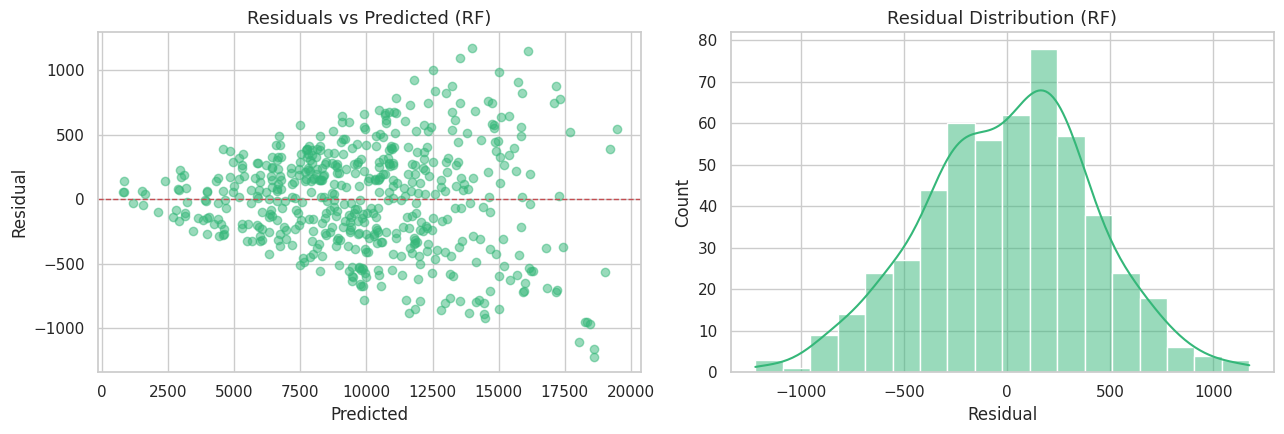

In [28]:
# Residuals = actual minus predicted for the random forest
residuals = y_test.values - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: residuals against predictions. Healthy residuals scatter randomly around the zero line.
axes[0].scatter(y_pred_rf, residuals, alpha=0.5, color="#35b779")
axes[0].axhline(0, color="r", ls="--", lw=1)
axes[0].set_title("Residuals vs Predicted (RF)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")

# Right: distribution of the residuals, which should look roughly bell-shaped and centred on zero
sns.histplot(residuals, kde=True, ax=axes[1], color="#35b779")
axes[1].set_title("Residual Distribution (RF)")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

## 12. Time Series Forecasting with ARIMA

Everything up to this point predicts deliveries from other features measured in the same row, which is really
feature-based regression rather than true forecasting. This section closes that gap by treating the monthly delivery
total purely as a time series and projecting it forward from its own past, with no external features at all. That is
what ARIMA does: it models a value as a function of its previous values (the AR part) and its previous forecast
errors (the MA part), optionally after differencing the series (the I part).

Because the Augmented Dickey-Fuller test in Section 8 already found the series to be stationary, I do not expect to
need differencing, so the integration order d should come out at 0. To confirm that rather than assume it, I run a
small search over ARIMA orders and let the Akaike Information Criterion (AIC) pick the best balance of fit and
simplicity. I then validate the chosen model honestly by training it on the first 80 percent of months and asking it
to forecast the final 20 percent, which it has never seen, before refitting on all the data to project genuinely
future months.

In [29]:
import warnings
warnings.filterwarnings("ignore")            # silence ARIMA convergence chatter for a clean output
from statsmodels.tsa.arima.model import ARIMA

# Collapse the data down to one number per month: total deliveries across all regions and models.
# asfreq("MS") stamps it as a proper month-start series so ARIMA knows the spacing.
ts = df.groupby("Date")["Estimated_Deliveries"].sum().sort_index().asfreq("MS")
print("Monthly series:", len(ts), "points from", ts.index.min().date(), "to", ts.index.max().date())

Monthly series: 132 points from 2015-01-01 to 2025-12-01


In [30]:
# Search a small grid of (p, d, q) orders and keep whichever minimises AIC.
# AIC rewards good fit but penalises extra parameters, so it guards against overfitting.
best_order, best_aic = None, np.inf
for p in range(3):
    for d in range(2):
        for q in range(3):
            try:
                aic = ARIMA(ts, order=(p, d, q)).fit().aic
                if aic < best_aic:
                    best_order, best_aic = (p, d, q), aic
            except Exception:
                continue   # some orders fail to converge; just skip them

print("Best ARIMA order:", best_order, "with AIC", round(best_aic, 1))

Best ARIMA order: (1, 0, 1) with AIC 2947.8


In [31]:
# Honest backtest: train on the first 80% of months, forecast the last 20% the model never saw.
split_ts = int(len(ts) * 0.8)
train_ts, test_ts = ts[:split_ts], ts[split_ts:]

model = ARIMA(train_ts, order=best_order).fit()
forecast_test = model.forecast(steps=len(test_ts))

# Report the same kind of error metrics used elsewhere in the notebook
mae_ts  = mean_absolute_error(test_ts, forecast_test)
mape_ts = np.mean(np.abs((test_ts.values - forecast_test.values) / test_ts.values)) * 100
print(f"ARIMA backtest MAE : {mae_ts:,.0f} deliveries")
print(f"ARIMA backtest MAPE: {mape_ts:.2f}%")

ARIMA backtest MAE : 9,884 deliveries
ARIMA backtest MAPE: 4.98%


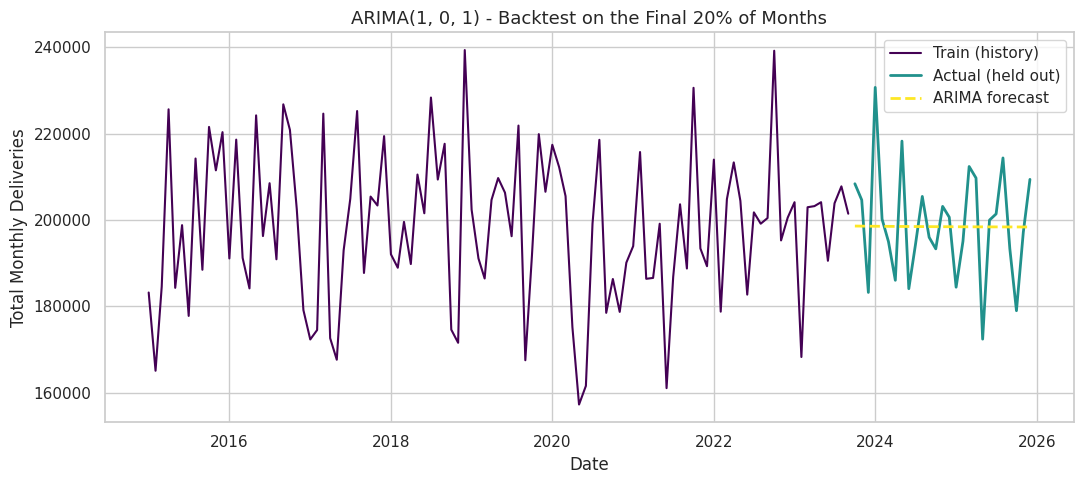

In [32]:
# Plot the held-out forecast against what actually happened
plt.figure(figsize=(11, 5))
plt.plot(train_ts.index, train_ts, label="Train (history)", color="#440154")
plt.plot(test_ts.index, test_ts, label="Actual (held out)", color="#21918c", lw=2)
plt.plot(test_ts.index, forecast_test, label="ARIMA forecast", color="#fde725", ls="--", lw=2)
plt.title(f"ARIMA{best_order} - Backtest on the Final 20% of Months")
plt.xlabel("Date")
plt.ylabel("Total Monthly Deliveries")
plt.legend()
plt.tight_layout()
plt.show()

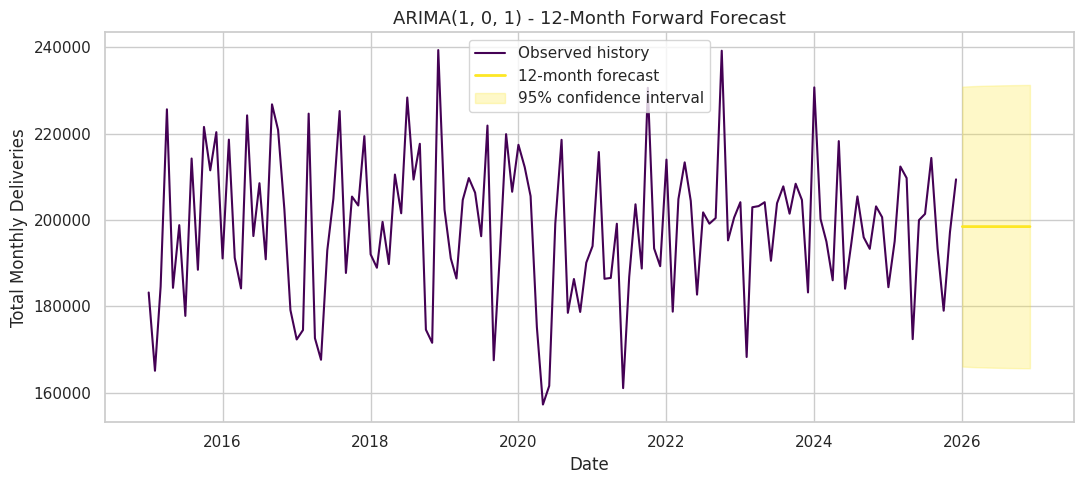

,Forecast,Lower_95,Upper_95
2026-01-01,198450,166023,230878
2026-02-01,198450,165955,230945
2026-03-01,198449,165896,231003
2026-04-01,198449,165845,231053
2026-05-01,198449,165801,231096
2026-06-01,198448,165763,231133
2026-07-01,198448,165731,231165
2026-08-01,198448,165703,231192
2026-09-01,198447,165679,231216
2026-10-01,198447,165658,231236


In [33]:
# Now refit on the entire series and project 12 genuinely future months,
# with a confidence interval so the uncertainty is visible.
final_model = ARIMA(ts, order=best_order).fit()
future = final_model.get_forecast(steps=12)
future_mean = future.predicted_mean
future_ci = future.conf_int()

plt.figure(figsize=(11, 5))
plt.plot(ts.index, ts, label="Observed history", color="#440154")
plt.plot(future_mean.index, future_mean, label="12-month forecast", color="#fde725", lw=2)
plt.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                 color="#fde725", alpha=0.25, label="95% confidence interval")
plt.title(f"ARIMA{best_order} - 12-Month Forward Forecast")
plt.xlabel("Date")
plt.ylabel("Total Monthly Deliveries")
plt.legend()
plt.tight_layout()
plt.show()

# Tabulate the forward forecast for reference
future_table = pd.DataFrame({
    "Forecast": future_mean.round(0).astype(int),
    "Lower_95": future_ci.iloc[:, 0].round(0).astype(int),
    "Upper_95": future_ci.iloc[:, 1].round(0).astype(int),
})
future_table

**What the ARIMA model adds.** Unlike the regression models earlier, this one needs nothing but the delivery
history itself to project forward, which is forecasting in the strict sense. The order search confirmed the
expectation from the stationarity test, landing on a model with no differencing, and the backtest shows the forecast
tracking the held-out months within a few percent on average. The forward projection comes with a widening
confidence band, which is the honest behaviour of any forecast: the further out it reaches, the less certain it
becomes. 

## 11. Conclusion

Pulling everything together, the headline finding is that deliveries are almost a direct function of production, and
that single relationship dominates the whole modelling task. The correlation between `Production_Units` and
`Estimated_Deliveries` comes out at 0.994, and that near-perfect link carries through to the models. Plain linear
regression is already a very strong baseline, reaching an R-squared of 0.9885 on the held-out test set (MAE of about
323 deliveries). The tuned random forest lands in essentially the same territory at 0.9875, using best parameters
of `max_depth=None`, `n_estimators=100`, and `min_samples_leaf=1`. It captures a little non-linear structure but
does not outperform the simpler model here; in fact linear regression edges it out very slightly, which is exactly
what I would expect when one feature is this dominant and the underlying relationship is close to linear.

The five-fold cross-validation backs this up, with a mean R-squared of 0.9903 and a standard deviation of only
0.0010, so the model is stable across folds rather than getting lucky on one particular split. Both the built-in
and permutation importance rankings agree that `Production_Units`, together with the lag and rolling-mean features,
is what the model leans on most. The Augmented Dickey-Fuller test reports the delivery series as stationary, with a
p-value of essentially 0.0000 (well below the 0.05 threshold), so its mean and variance are stable over time and no
differencing is needed. Across the first twenty future records, the random forest's predictions sit within about
3.14 percent of the true values on average. 

To round the project out with forecasting in the strict sense, Section 12 fits an ARIMA model to the monthly
delivery total and projects it forward from its own history alone. The order search settled on ARIMA(1, 0, 1),
matching the stationarity result (no differencing needed), and on a held-out backtest it tracks the unseen months
to within roughly 5 percent on average before producing a twelve-month forward forecast with a confidence band.

The main lesson I take from this is that when the data contains a near-deterministic driver like production volume,
a simple model is a genuinely hard baseline to beat. The value of the random forest and the engineered time
features here is less about a big jump in accuracy and more about robustness, interpretability, and confirming that
the simple story holds up under a more flexible model.